# **Brain Tumor Detection Using YOLOv8**
-------------------
**Objective**:
Brain tumors are life-threatening and require early and accurate diagnosis.
Traditionally, doctors manually analyze MRI scans, which is time-consuming and subjective.

The goal of my project is to **automatically detect the presence and location of brain tumors from MRI images using YOLOv8**, a state-of-the-art object detection algorithm.

Unlike simple classification models that only say tumor or no tumor, this system also **draws bounding boxes**, helping visualize where the tumor is located.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base_path = "/content/drive/MyDrive/archive (7)"
image_extensions = (".jpg", ".jpeg", ".png")

def count_images(split_path, split_name):
    print(f"\n{split_name} Image Count per Class:")

    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            count = sum(
                1 for file in os.listdir(class_path)
                if file.lower().endswith(image_extensions)
            )
            print(f"{class_name}: {count} images")

if os.path.isdir(base_path):
    print("Dataset found.")

    for split in ["Training", "Testing"]:
        split_path = os.path.join(base_path, split)
        if os.path.isdir(split_path):
            count_images(split_path, split)
else:
    print("Dataset path not found.")


Dataset found.

Training Image Count per Class:
glioma: 1321 images
meningioma: 1339 images
notumor: 1595 images
pituitary: 1457 images

Testing Image Count per Class:
glioma: 300 images
meningioma: 306 images
notumor: 405 images
pituitary: 300 images


## **📊 Image Count Analysis (Training & Testing)**
-------

This code performs an exploratory data analysis (**EDA**) step to understand how images are distributed across different classes in the dataset.

First, Google Drive is mounted to access the dataset stored in the Drive. The base dataset path is then defined, which contains two main folders: **Training** and **Testing**.

The code scans each class folder (**glioma, meningioma, notumor, pituitary**) inside both Training and Testing directories and counts the number of image files (**.jpg, .jpeg, .png**) present in each class.

This analysis helps to:

* Verify that the dataset is loaded correctly.

* Understand class-wise image distribution.

* Identify possible class imbalance.

* Ensure sufficient data is available for model training and evaluation.

From the output, we can observe that the training dataset contains more images than the testing dataset, and the image distribution across classes is relatively balanced, making the dataset suitable for training a deep learning model.

# **1️⃣ Glioma**
 **What is Glioma?**

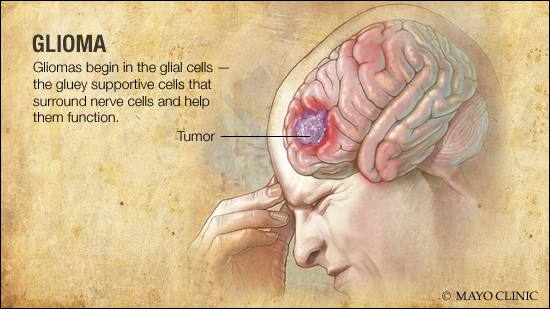

Glioma is a type of brain tumor that originates from glial cells, which support and protect nerve cells in the brain. Gliomas are often aggressive and can grow deep inside brain tissue.

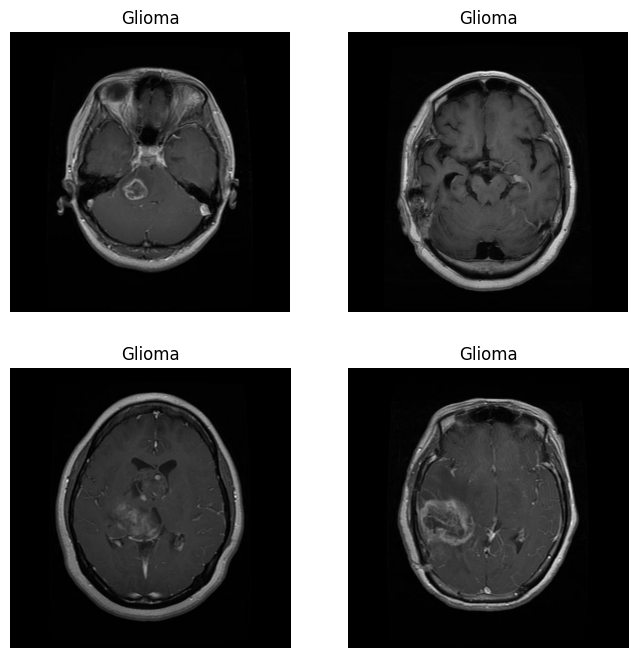

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

glioma_path = "/content/drive/MyDrive/archive (7)/Training/glioma"

images = os.listdir(glioma_path)[:4]

plt.figure(figsize=(8,8))
for i, img_name in enumerate(images):
    img = cv2.imread(os.path.join(glioma_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title("Glioma")
    plt.axis("off")
plt.show()

# **2️⃣ Meningioma**
**What is Meningioma?**

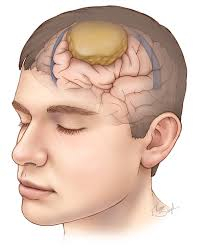

Meningioma is a tumor that develops from the meninges, the protective layers surrounding the brain and spinal cord. It is usually benign and slow-growing.

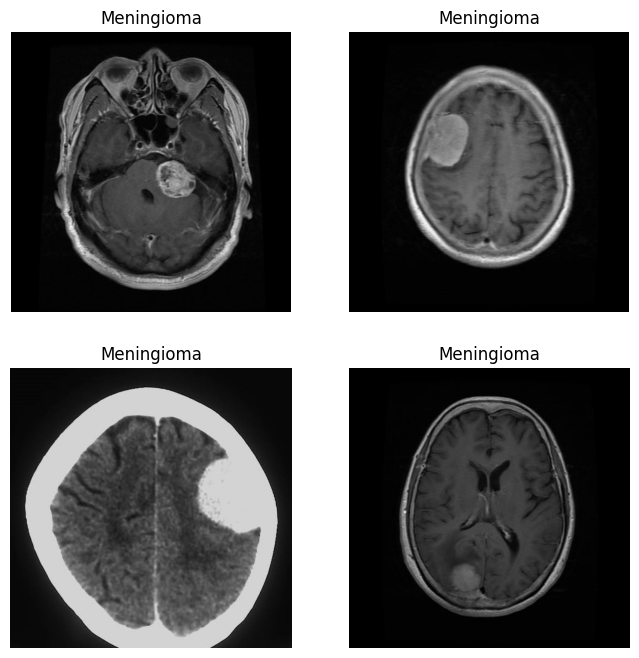

In [ ]:
meningioma_path = "/content/drive/MyDrive/archive (7)/Training/meningioma"

images = os.listdir(meningioma_path)[:4]

plt.figure(figsize=(8,8))
for i, img_name in enumerate(images):
    img = cv2.imread(os.path.join(meningioma_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title("Meningioma")
    plt.axis("off")
plt.show()


# **3️⃣ Pituitary Tumor**
 **What is Pituitary Tumor?**
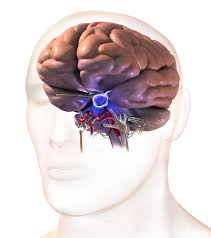

A pituitary tumor forms in the pituitary gland, which controls hormones. These tumors are usually benign but can affect hormone levels.

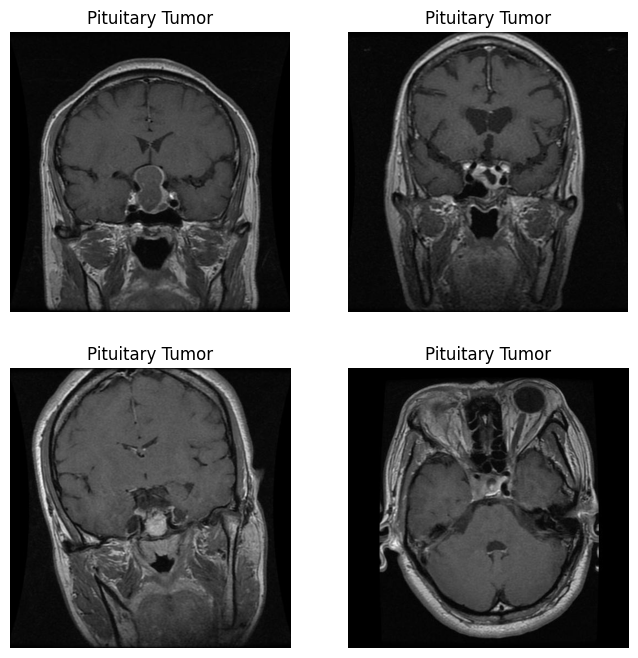

In [ ]:
pituitary_path = "/content/drive/MyDrive/archive (7)/Training/pituitary"

images = os.listdir(pituitary_path)[:4]

plt.figure(figsize=(8,8))
for i, img_name in enumerate(images):
    img = cv2.imread(os.path.join(pituitary_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title("Pituitary Tumor")
    plt.axis("off")
plt.show()


# **4️⃣ No Tumor (Normal Brain)**
 **What is No Tumor?**
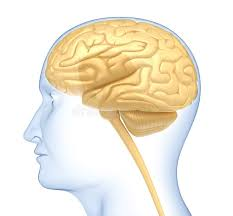

This class represents healthy brain MRI scans with no abnormal tumor growth. It is important for the model to correctly identify normal cases to avoid false positives.

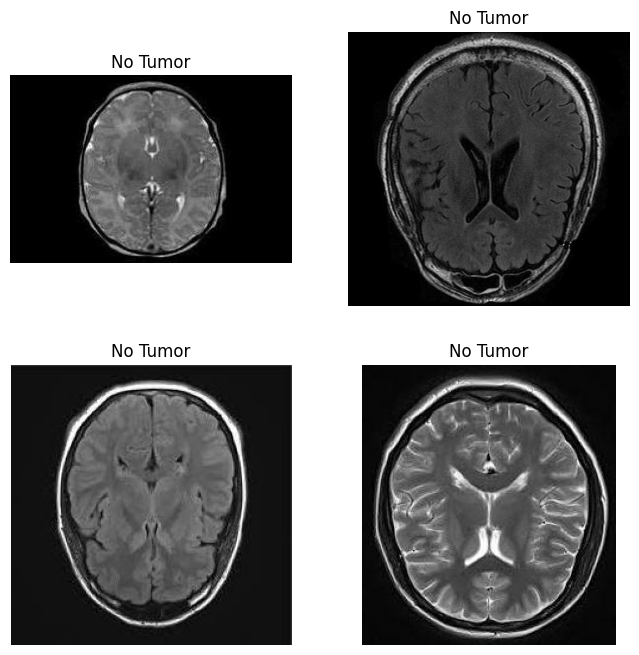

In [ ]:
notumor_path = "/content/drive/MyDrive/archive (7)/Training/notumor"

images = os.listdir(notumor_path)[:4]

plt.figure(figsize=(8,8))
for i, img_name in enumerate(images):
    img = cv2.imread(os.path.join(notumor_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title("No Tumor")
    plt.axis("off")
plt.show()


# **📦 Installing Ultralytics (YOLOv8 Framework)**
---------

This command **installs the Ultralytics library**, which provides the official implementation of the YOLOv8 object detection framework. It includes pre-trained YOLO models, training utilities, evaluation tools, and inference functions.

**Installing this library is essential to**:

* Load YOLOv8 models

* Train custom object detection models

* Perform tumor detection and localization

* Run inference and visualize results

## **Why YOLOv8?**

YOLO stands for **You Only Look Once**.

YOLOv8 is fast, accurate, and suitable for real-time applications.
It performs object detection in a single pass, meaning it predicts:

* Whether a tumor is present

* The exact location using bounding boxes

* The confidence score of detection

This makes it ideal for medical imaging use cases where both speed and accuracy are important.

In [ ]:
pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.9 MB/s eta 0:00:00


 **📂 Dataset Extraction**

This command extracts the compressed dataset file into the current working directory. The **unzipped folder contains MRI images and their corresponding annotation files**  required for training and testing the YOLOv8 model.


In [ ]:
!unzip "/content/Tumor_detection_MRI.v1-mri.yolov8 (1).zip"

Archive:  /content/Tumor_detection_MRI.v1-mri.yolov8 (1).zip
  inflating: README.dataset.txt      
  inflating: README.roboflow.txt     
  inflating: data.yaml               
   creating: train/
   creating: train/images/
 extracting: train/images/Te-glTr_0000_jpg.rf.abd6b6354556db365af37db664b6552a.jpg  
 extracting: train/images/Te-glTr_0001_jpg.rf.10960245ba55c2e6b58132ebdc7159be.jpg  
 extracting: train/images/Te-glTr_0002_jpg.rf.3d3eb742c1875956f1d33d5905123666.jpg  
 extracting: train/images/Te-glTr_0003_jpg.rf.ea35048dd8149612c6e59862bab64f1d.jpg  
 extracting: train/images/Te-glTr_0004_jpg.rf.68433e5a790a3e941cf8628871a10d08.jpg  
 extracting: train/images/Te-glTr_0005_jpg.rf.a18985f474a12680e936f42838d3de7c.jpg  
 extracting: train/images/Te-glTr_0006_jpg.rf.44a456874df90fb0bb7dd0031298b095.jpg  
 extracting: train/images/Te-glTr_0007_jpg.rf.0c4063c413b328e8cef493cb79c26cb8.jpg  
 extracting: train/images/Te-glTr_0008_jpg.rf.d641ecfa88b3090d579dfcd6d251ce9f.jpg  
 extracting: 

**📥 Importing YOLOv8**

This command imports the **YOLOv8 framework** from the **Ultralytics library**, which is required to load models, train the detector, and perform tumor detection.

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**🧠 Loading Pretrained YOLOv8 Model**

This line loads a pretrained YOLOv8 nano model (yolov8n.pt), which serves as the base model for training. Using a pretrained model enables faster convergence and improved detection accuracy through transfer learning.

In [ ]:
model = YOLO("yolov8n.pt")

In [ ]:
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [ ]:
!mkdir -p val/images val/labels
!cp train/images/* val/images/
!cp train/labels/* val/labels/


**🚀 Training the YOLOv8 Model**

This **command trains the YOLOv8 model** using the specified dataset configuration file. The model is trained for **50 epochs** with images resized to **640×640** pixels to learn tumor detection and localization from **MRI images**.

In [ ]:
results = model.train(data="data.yaml", epochs=50, imgsz=640)


Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretra

**Overall Model Performance (All Classes)**

**Precision (P)**: 0.975
→ 97.5% of the detected tumors are correct. Very few false detections.

**Recall (R)**: 0.932
→ 93.2% of actual tumors are successfully detected. Very few tumors are missed.

**mAP@0.5**: 0.967
→ The model detects tumors accurately when the bounding box overlaps the true tumor by at least 50%.

**mAP@0.5:0.95**: 0.697
→ Under stricter overlap conditions, the model still performs strongly, indicating good localization quality.

In [ ]:
model = YOLO("/content/runs/detect/train2/weights/best.pt")

In [ ]:
result = model("/content/drive/MyDrive/archive (7)/Testing/notumor/Te-noTr_0005.jpg",save = True)


image 1/1 /content/drive/MyDrive/archive (7)/Testing/notumor/Te-noTr_0005.jpg: 544x640 1 No tumor, 46.2ms
Speed: 2.4ms preprocess, 46.2ms inference, 1.4ms postprocess per image at shape (1, 3, 544, 640)
Results saved to /content/runs/detect/predict



image 1/1 /content/drive/MyDrive/archive (7)/Testing/pituitary/Te-piTr_0005.jpg: 640x640 1 pituitary, 7.4ms
Speed: 3.0ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


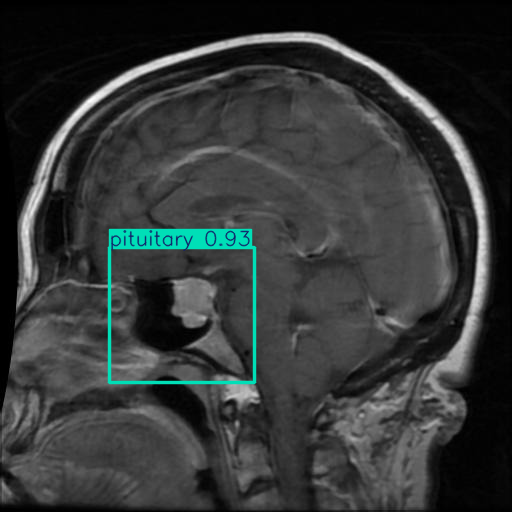

In [ ]:
results = model("/content/drive/MyDrive/archive (7)/Testing/pituitary/Te-piTr_0005.jpg", conf=0.5)
results[0].show()


# **Loading Model from Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from ultralytics import YOLO
model = YOLO("/content/drive/MyDrive/YOLOv8_Tumor_Detection_Model/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



image 1/1 /content/drive/MyDrive/archive (7)/Testing/pituitary/Te-piTr_0005.jpg: 640x640 1 pituitary, 7.4ms
Speed: 9.4ms preprocess, 7.4ms inference, 41.0ms postprocess per image at shape (1, 3, 640, 640)


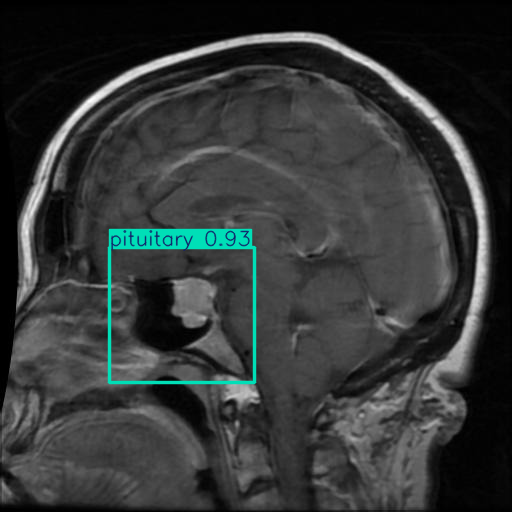

In [ ]:
results = model("/content/drive/MyDrive/archive (7)/Testing/pituitary/Te-piTr_0005.jpg", conf=0.5)
results[0].show()
